# Analysis


In [1]:
## Imports we'll need

import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default') # seaborn, ggplot
import matplotlib.cm as cm

#It tells Pandas: "Stop using 'e' notation 
# and just show me two decimal places for all floats."
pd.options.display.float_format = '{:,.2f}'.format


data_file = '../data/clean_data_for_analysis.csv'
df = pd.read_csv(data_file)

df['zip_code'] = df['zip_code'].astype('int')




### Explore Data

- **Creating a regions columns:**
    Based on zipcode, needed for some analysis

- **Recount** : 26655 rows, 24 columns 

- **Visualizing health_data**
    Examined data health in total and by property type:
    - -> Created data_health, the average of missing values per columns **! High number = Healthy !**
    - -> data_health_by_type, the same grouped by type of properties **! High number = Healthy !**


- **Distributions**


- **Correlations**


<Axes: xlabel='property_type'>

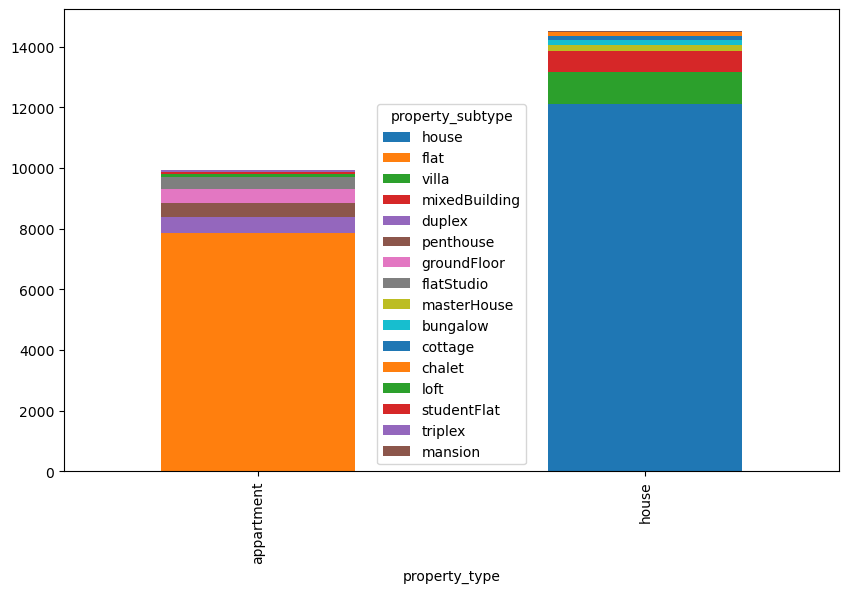

In [2]:
# My tests
#df['property_type'].value_counts().plot(kind="bar")
#print(df['property_type'].value_counts())
#print("Index:", df['property_type'].value_counts().index)
#print("Values:", df['property_type'].value_counts().values)

#df.groupby('property_type')['property_subtype'].value_counts().plot(kind='bar')
#df.groupby('property_type')['property_subtype'].value_counts().unstack().plot(kind='bar', stacked=True, ax=axes[1])
test = df.groupby('property_type')['property_subtype'].value_counts().unstack()
test = test[test.sum().sort_values(ascending=False).index]
test.plot(kind='bar', stacked=True, figsize=(10, 6))



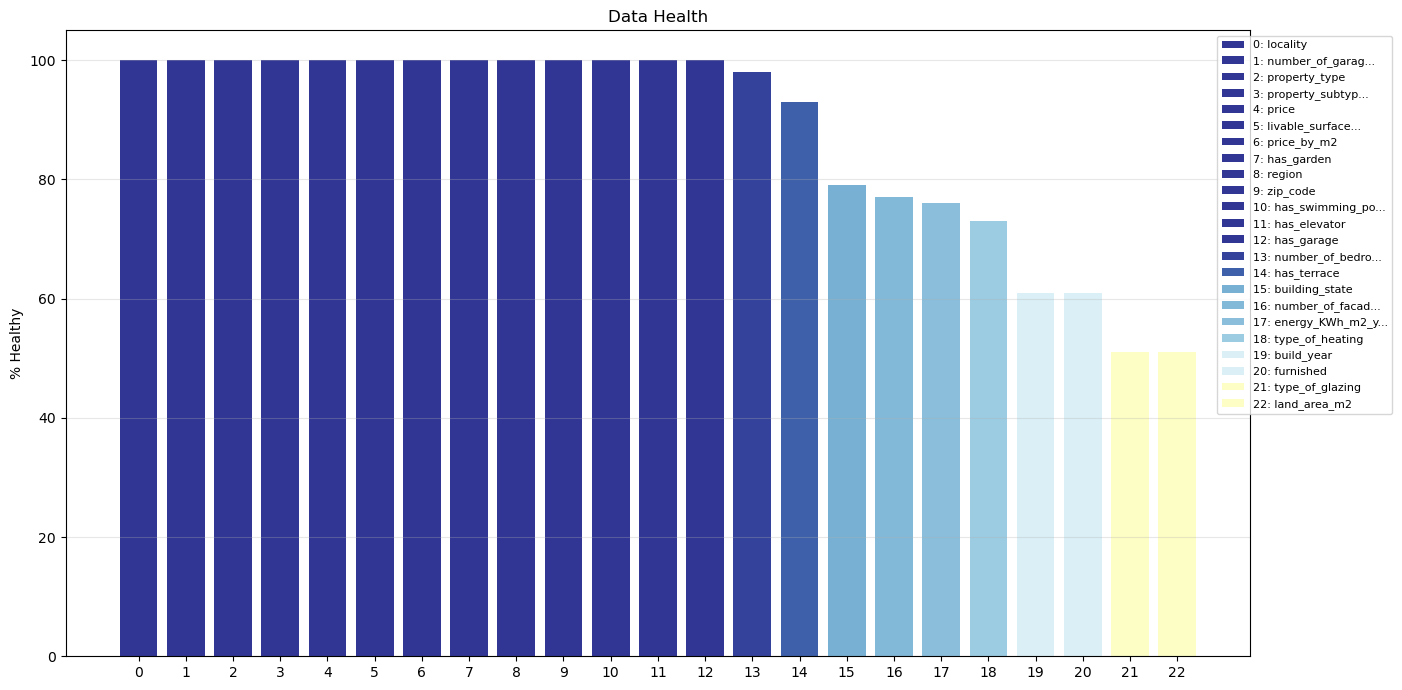

In [ ]:
## Visualizing health_data
data_health = (100-(df.isna().mean()*100)).round().sort_values(ascending=False)

## Working on colors:
cmap = plt.get_cmap('RdYlBu') # get the colormap into a variable.
norm = plt.Normalize(vmin=0, vmax=100) # normalise the values for the colormap
colors = cmap(norm(data_health.values)) # sets colors as the color map, on the normalise values, on the values

## Setting the stage of the graph.
fig, ax = plt.subplots(figsize=(14,7),)
labels = [label[:15]+"..." if len(label) > 15 else label for label in data_health.index]
labels_num = list(range(len(data_health.index)))
legends = []
for i in range(len(labels)):
    legends.append(f"{i}: {labels[i]}")


### Building the graph
bars = ax.bar(data_health.index, data_health.values, color=colors ) #color='coolwarm' # color="plasma"
ax.set_title("Data Health")
ax.set_ylabel("% Healthy")
ax.grid(True, alpha=0.3, axis="y")
ax.set_xticks(range(len(data_health.index)))
ax.set_xticklabels(labels_num)
ax.legend(bars, legends, loc="upper right", bbox_to_anchor=(1.125, 1), fontsize=8, frameon=True)

plt.xticks()
plt.tight_layout()
plt.show()

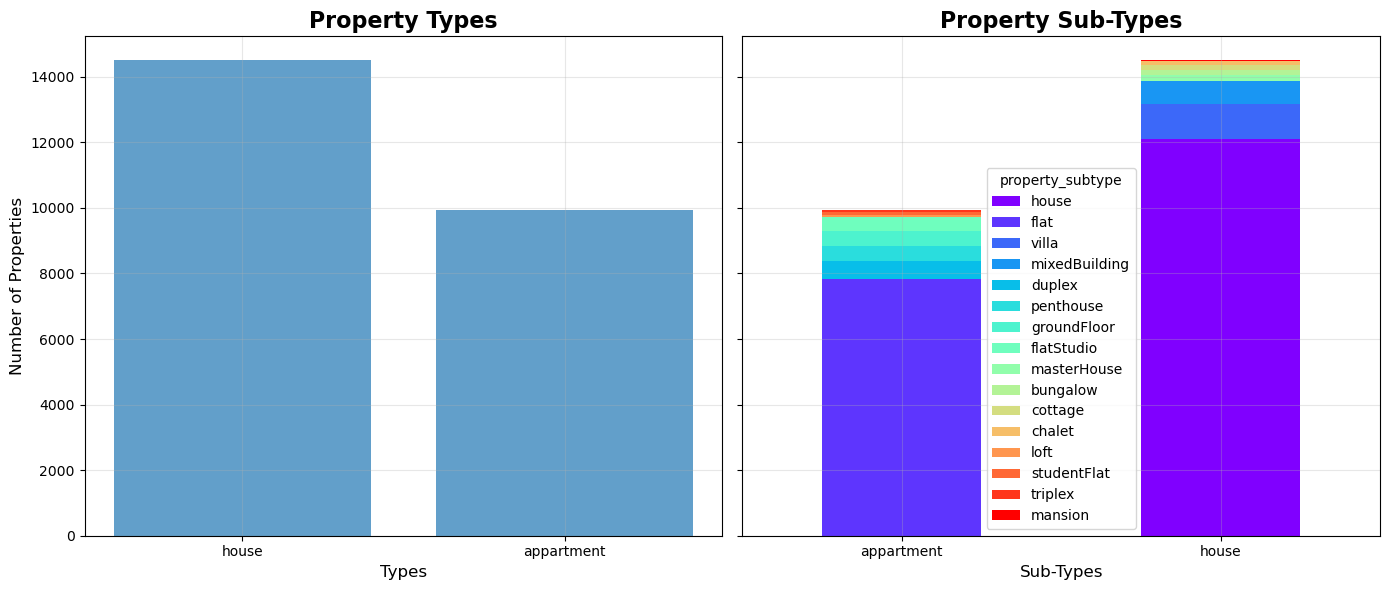

In [5]:
### Proportion of properties:
df['property_type'].value_counts()
subtypes = df['property_subtype'].value_counts()
types = df['property_type'].value_counts()
test = df.groupby('property_type')['property_subtype'].value_counts().unstack()
test = test[test.sum().sort_values(ascending=False).index]

#df.groupby('property_type')['property_subtype'].value_counts().unstack().plot(kind='bar', stacked=True, ax=axes[1])
#test.plot(kind='bar', stacked=True, ax=axes[1])

fig, axes = plt.subplots(1,2, figsize=(14, 6), sharey=True)

axes[0].bar(types.index, types.values,
    alpha=0.7)


#axes[1].bar(subtypes.index, subtypes.values)

axes[0].set_title('Property Types', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Types', fontsize=12)
axes[0].set_ylabel('Number of Properties', fontsize=12)
axes[0].grid(True, alpha=0.3)

test.plot(kind='bar', stacked=True, ax=axes[1], colormap='rainbow')
#axes[1].bar(test.index, test.values, alpha=0.7)
axes[1].set_title('Property Sub-Types', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Sub-Types', fontsize=12)
axes[1].set_ylabel('Number of Properties', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()



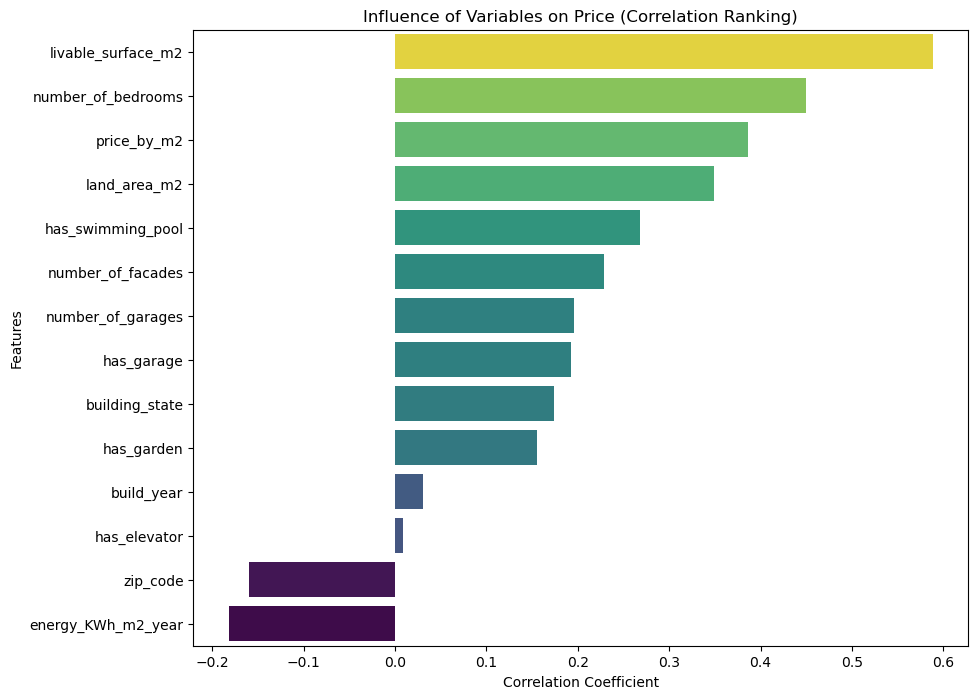

In [6]:
### Correlation heatmap
# 1. Isolate the 'price_eur' column from the correlation matrix
# and sort the values so the highest is at the top
# 2. We remove 'price_eur' itself (because it's always 1.0)
price_correlations = df.corr(numeric_only=True)['price'].sort_values(ascending=False).drop('price')#.drop('zip_code')
#print(f"{price_correlations=}")

# 3. Setup the drawing
plt.figure(figsize=(10, 8))

# 4. Create the bar plot
# We use the 'index' (column names) for the Y axis 
# and the 'values' (the correlation numbers) for the X axis
sns.barplot(x=price_correlations.values, y=price_correlations.index, palette='viridis', hue=price_correlations, legend=False)

# 5. Add labels
plt.title('Influence of Variables on Price (Correlation Ranking)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.show()




In [27]:
median_price = df['price_by_m2'].median()
print(median_price)

2463.86


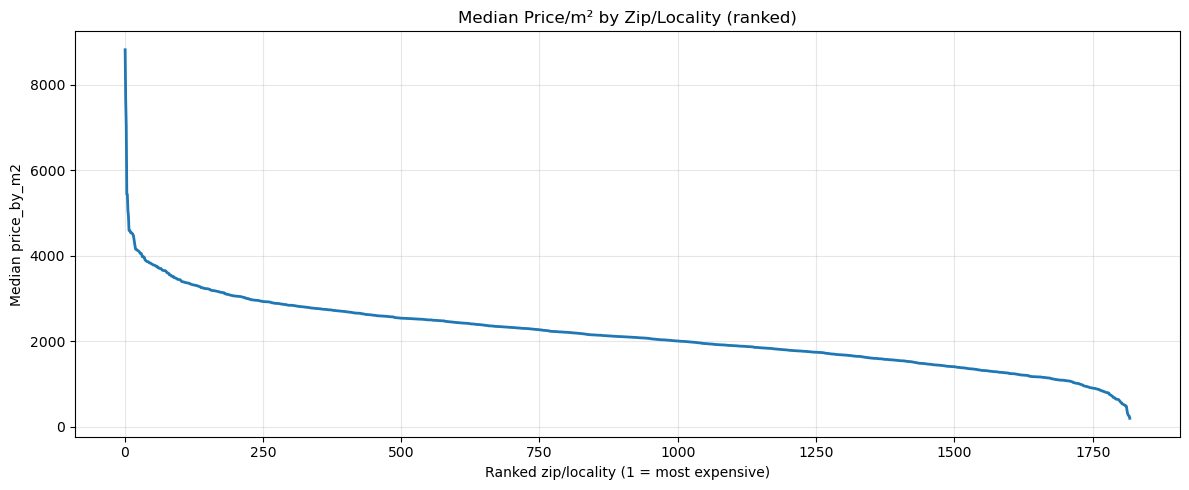

In [7]:
### Distribution of prices : look how high and low it goes

# all_prices_by_zip is your sorted Series (descending)
all_prices_by_zip = df.groupby(['zip_code', 'locality'])['price_by_m2'].median().sort_values(ascending=False).round(2)

s = all_prices_by_zip.sort_values(ascending=False).reset_index(name='price_by_m2')
s['rank'] = range(1, len(s) + 1)

plt.figure(figsize=(12, 5))
plt.plot(s['rank'], s['price_by_m2'], linewidth=2)
plt.title('Median Price/m² by Zip/Locality (ranked)')
plt.xlabel('Ranked zip/locality (1 = most expensive)')
plt.ylabel('Median price_by_m2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

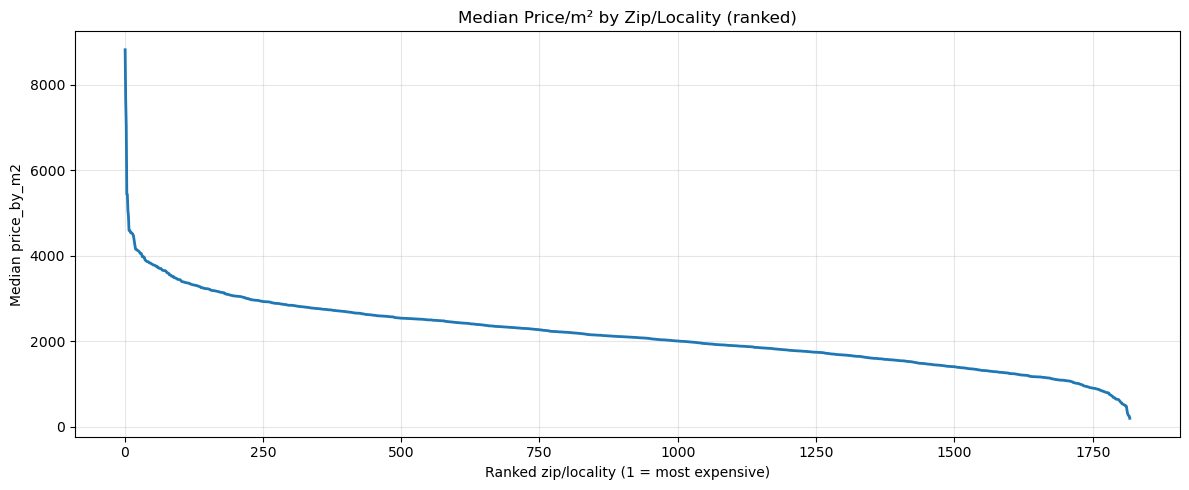

In [25]:
# all_prices_by_zip is your sorted Series (descending)
fig, ax = plt.subplots(figsize=(12, 5))
all_prices_by_zip = df.groupby(['zip_code', 'locality'])['price_by_m2'].median().sort_values(ascending=False).round(2)
s = all_prices_by_zip.sort_values(ascending=False).reset_index(name='price_by_m2')
s['rank'] = range(1, len(s) + 1)

ax.plot(s['rank'], s['price_by_m2'], linewidth=2)
ax.set_title('Median Price/m² by Zip/Locality (ranked)')
ax.set_xlabel('Ranked zip/locality (1 = most expensive)')
ax.set_ylabel('Median price_by_m2')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Price distribution (<1M€)'}, ylabel='Frequency'>

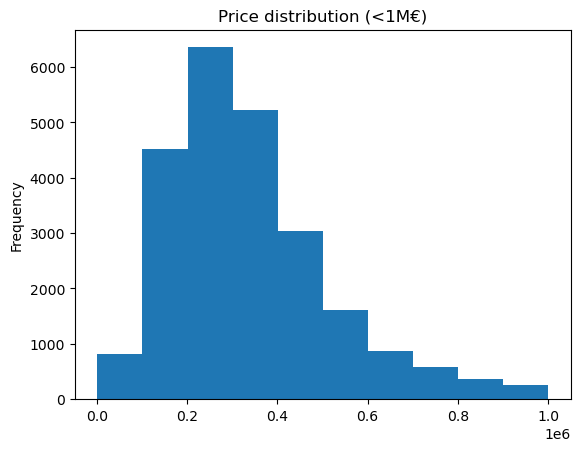

In [8]:
## Seeing prices
# I want to see the spread of prices : the median, the iQR and the outlier
df[df['price'] < 1_000_000]['price'].plot(kind="hist", title="Price distribution (<1M€)")


In [9]:
df.groupby('zip_code')['price'].median().round(2).sort_values(ascending=False)#.plot(kind='hist')

zip_code
9961   2,698,000.00
8510   1,490,000.00
3806   1,397,500.00
6661     998,000.00
1950     995,000.00
           ...     
5541      84,500.00
5520      79,000.00
5542      66,750.00
5561      65,000.00
4171      37,500.00
Name: price, Length: 998, dtype: float64

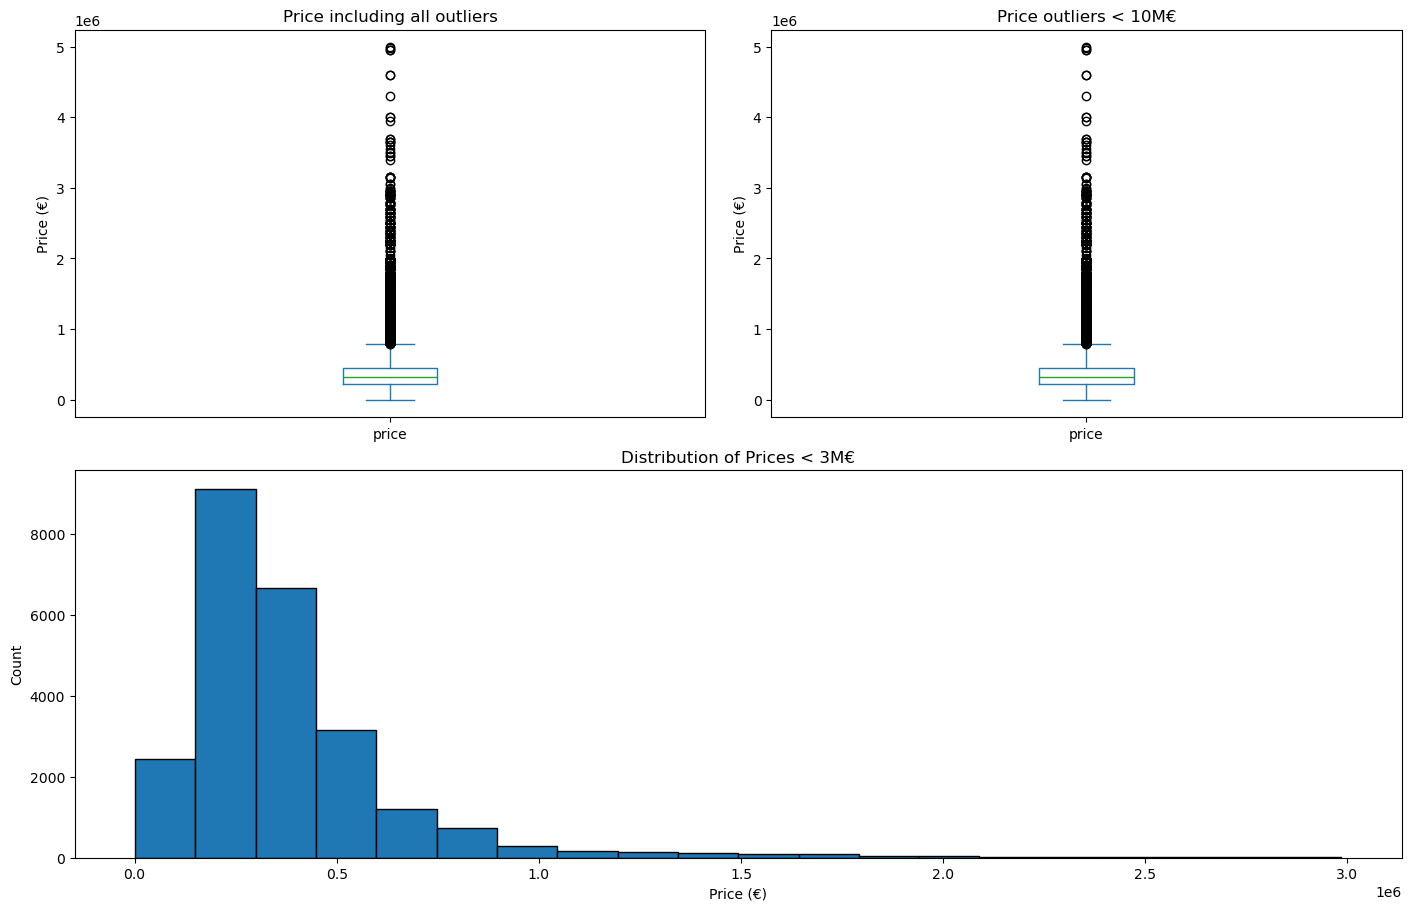

In [10]:
## Vizualize price distributions:


fig = plt.figure(figsize=(14, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])   # bottom row, full width

df["price"].plot.box(ax=ax1)
ax1.set_title("Price including all outliers")
ax1.set_ylabel("Price (€)")

df.loc[df["price"] <= 10_000_000, "price"].plot.box(ax=ax2)
ax2.set_title("Price outliers < 10M€")
ax2.set_ylabel("Price (€)")

df.loc[df["price"] < 3_000_000, "price"].plot.hist(ax=ax3, bins=20, edgecolor="k")
ax3.set_title("Distribution of Prices < 3M€")
ax3.set_xlabel("Price (€)")
ax3.set_ylabel("Count")

plt.show()


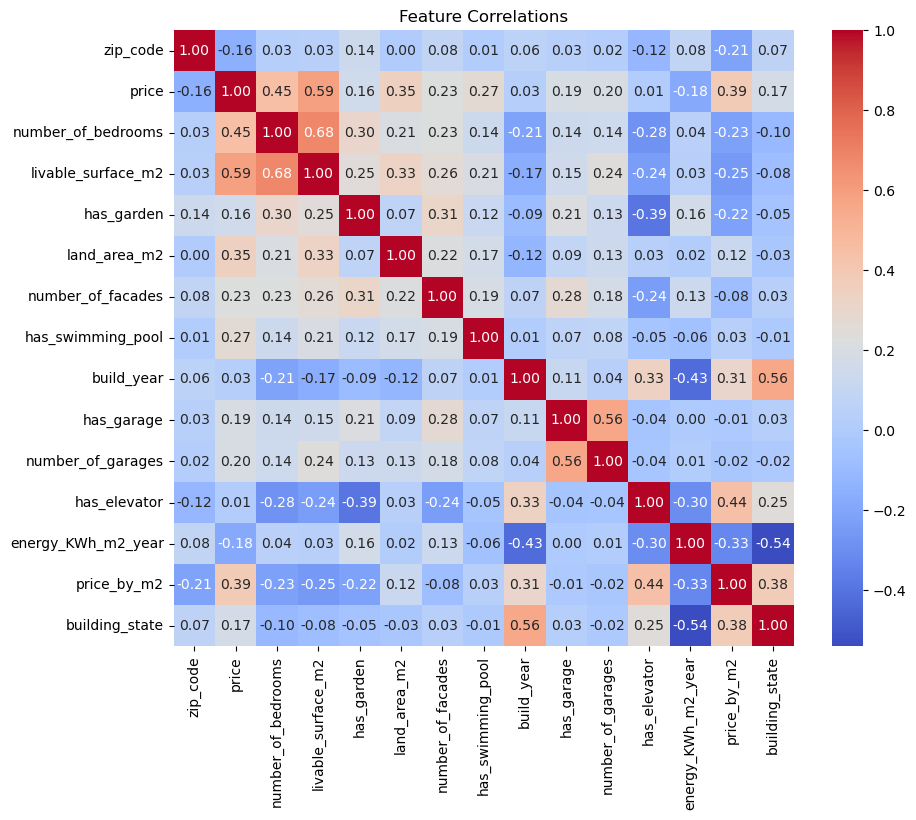

In [11]:
## Correlations
corr_matrix = df.corr(numeric_only=True)
#print(corr_matrix.sort_values)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlations")
plt.show()


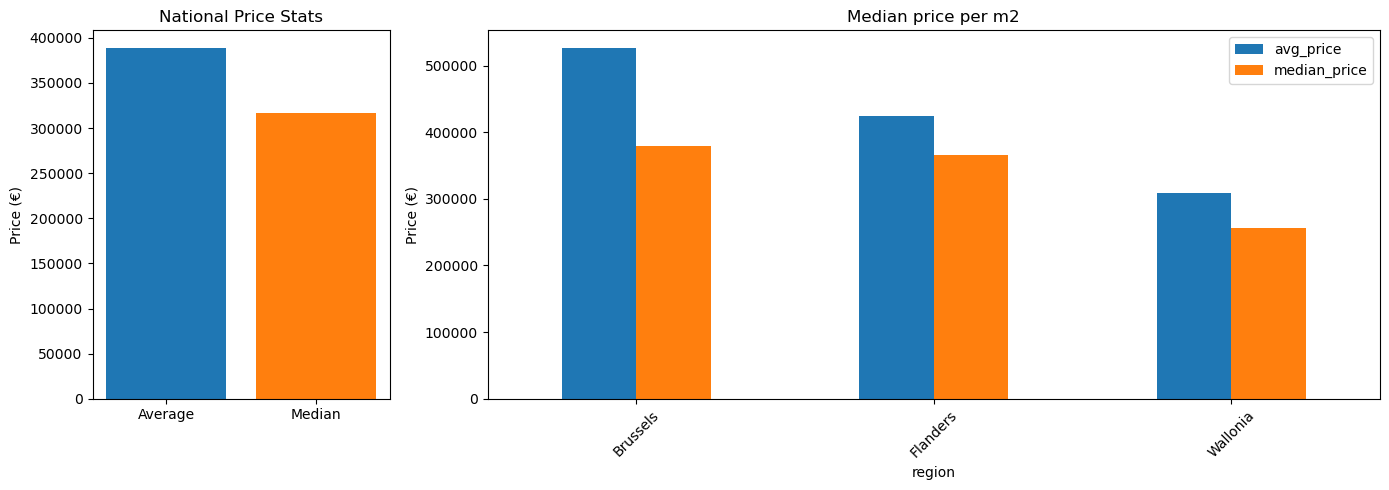

In [12]:
## Showing prices by region

# 3) National stats
national_avg = df["price"].mean()
national_median = df["price"].median()

# 4) Regional stats
regional_stats = (
    df.groupby("region")["price"]
    .agg(avg_price="mean", median_price="median")
    .sort_values("avg_price", ascending=False))


# 5) Graphs: national first, then regions
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 3]})

# National chart
axes[0].bar(["Average", "Median"], [national_avg, national_median], color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("National Price Stats")
axes[0].set_ylabel("Price (€)")

# Regional chart
regional_stats[["avg_price", "median_price"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Median price per m2")
axes[1].set_ylabel("Price (€)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [13]:
# What are the **most** expensive municipalities in Belgium? 
# #(Average price, median price, price per square meter)

#df.groupby('zip_code')[['price', "price_by_m2"]].agg("mean", 'median')
df.groupby('zip_code')['price']



#median_most_expensive_cities = df.groupby('zip_code')['price'].median().sort_values(ascending=False).head(5)
#median_least_expensive_cities = df.groupby('zip_code')['price'].median().sort_values(ascending=False).tail(5)


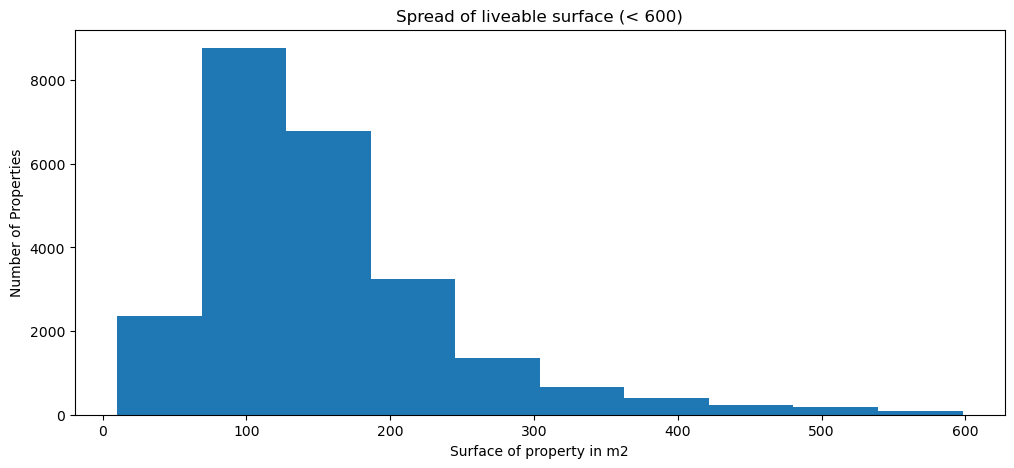

In [14]:
### Properties numbers by surface area histogram:

#df.loc[df['livable_surface_m2' < '1000', 'livable_surface_m2']].sort_values()
spread = df[df['livable_surface_m2'] < 600]['livable_surface_m2']


plt.figure(figsize=(12, 5))
plt.hist(spread)
plt.title("Spread of liveable surface (< 600)")
plt.ylabel('Number of Properties')
plt.xlabel('Surface of property in m2')
plt.show()

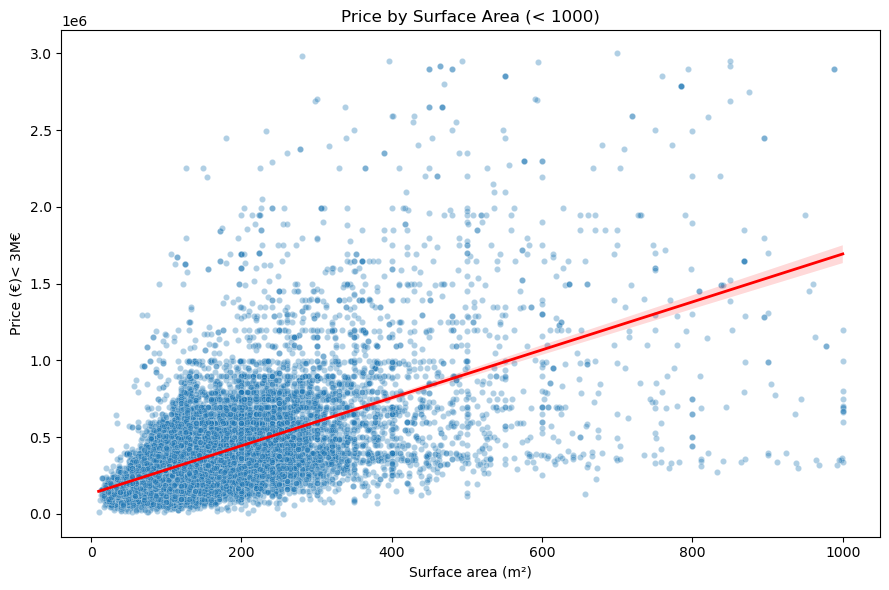

In [15]:
### Properties by surface area Scatter plot:

# keep only usable rows
#plot_df = df[['price', 'livable_surface_m2']].dropna()


# With limits
MAX_PRICE = 3_000_000
MAX_AREA = 1000

plot_df = (
    df[['price', 'livable_surface_m2']]
    .dropna()
    .query('price <= @MAX_PRICE and livable_surface_m2 <= @MAX_AREA')
)


plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='livable_surface_m2', y='price', alpha=0.35, s=20)
sns.regplot(data=plot_df, x='livable_surface_m2', y='price', scatter=False, color='red', line_kws={'lw': 2})
plt.title('Price by Surface Area (< 1000)')
plt.xlabel('Surface area (m²)')
plt.ylabel('Price (€)< 3M€')
plt.tight_layout()
plt.show()


In [16]:
#all_prices_by_zip = df.groupby(['zip_code', 'locality'])['price_by_m2'].median().sort_values(ascending=False).round(2).plot()
all_prices_by_zip = df.groupby(['zip_code', 'locality'])['price_by_m2'].median().sort_values(ascending=False).round(2)

national_median = df['price_by_m2'].median()

print(national_median)



2463.86


In [17]:
df.groupby('property_subtype')['property_subtype'].value_counts()

property_subtype
bungalow           158
chalet             123
cottage            158
duplex             532
flat              7839
flatStudio         415
groundFloor        448
house            12098
loft                79
mansion             22
masterHouse        185
mixedBuilding      684
penthouse          482
studentFlat         77
triplex             60
villa             1081
Name: count, dtype: int64